# 1. Mô tả

- File này để trả lời 2 câu hỏi có thể trả lời được dựa vào dữ liệu sẵn có. Ngoài ra, để tăng thách thức (aka công việc), các câu hỏi này để trả lời thiếu phục, ý nghĩa và phù hợp với thực tế còn cần nhóm phải tra cứu, tìm tòi, tích hợp thêm một số thông tin bên ngoài. 

- Các câu hỏi chỉ dựa vào mỗi dữ liệu `original_data` để trả lời, rút ra insight và giả thuyết đã được nhóm trình bày ở **02_general_eda.ipynb**. 

- Nghĩa là nhóm đã có và trình bày nhiều hơn 4 câu hỏi / giả thuyết, và 4 câu hỏi được trình bày ở 2 file 03.ipynb là những câu hỏi khó, thử thách nhất.

In [1]:
# import thư viện cần thiết

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=FutureWarning) # tắt các cảnh báo

df_original = pd.read_csv('../data/drop_dup_data.csv')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# 2. Câu hỏi

Sau khi thực hiện xong câu hỏi 1 và ngẫm, nhìn lại thì nhóm phát hiện ra câu hỏi có vấn đề về thời gian. Câu trả lời bị ảnh hưởng bởi thời gian, do đó cần đảm bảo thống nhất về cột mốc thời gian trong các dữ liệu được phân tích. Và để mang ý nghĩa cao nhất (cũng như phù hợp nhất với bộ dữ liệu này), nên khảo sát dữ liệu thuộc năm 2024 - 2025.


## Câu hỏi 1: So sánh sức mua (PPP): Lương $15k ở Châu Á có 'nghèo' hơn $100k ở Mỹ?

### 1. Mô tả câu hỏi
Trong các báo cáo lương toàn cầu, con số tuyệt đối thường gây hiểu lầm. Mức lương $15,000/năm tại Việt Nam hay Ấn Độ nghe có vẻ rất thấp so với mức $150,000/năm tại Mỹ. Tuy nhiên, chi phí sinh hoạt và mức sống tại mỗi quốc gia là khác nhau.

Câu hỏi này sử dụng dữ liệu **GDP theo sức mua tương đương (GDP PPP per capita)** để chuẩn hóa mức lương, từ đó so sánh "vị thế xã hội" thực sự của nhân sự ngành Data Science tại các quốc gia khác nhau.

### 2. Ý nghĩa câu hỏi

* **Giá trị thực tế:**
    * Giúp loại bỏ "ảo giác tiền tệ" khi so sánh lương giữa các nước phát triển và đang phát triển.

    * Đánh giá được mức đãi ngộ thực tế dựa trên bối cảnh kinh tế địa phương.

* **Insight:**
    * Xác định xem tại quốc gia nào thì nghề Data Science mang lại cuộc sống "dư dả" nhất so với mặt bằng chung.

    * Trả lời câu hỏi: Liệu chấp nhận mức lương thấp hơn ở quê nhà có mang lại chất lượng cuộc sống (về mặt tài chính tương đối) tốt hơn là sang nước ngoài làm việc với chi phí đắt đỏ không.

* **Đối tượng quan tâm:**
    * **Người tìm việc:** Cân nhắc giữa việc ở lại trong nước (như Việt Nam, Ấn Độ) hay tìm đường xuất ngoại.

    * **Digital Nomads:** Những người làm việc từ xa muốn tìm kiếm các quốc gia có mức lương ngành cao so với chi phí sống thấp để tối ưu hóa thu nhập.
    * **Nhà tuyển dụng toàn cầu:** Hiểu mức lương cạnh tranh tại địa phương để đưa ra offer hợp lý mà không cần phải trả mức lương chuẩn Mỹ.

### A. Tiền xử lý dữ liệu

**Mô tả quy trình:**

Để trả lời câu hỏi này, ta cùng thực hiện các bước sau:

1.  **Khởi tạo dữ liệu:** Tạo một bản sao độc lập từ dữ liệu gốc (`df_original`) để đảm bảo không làm thay đổi dữ liệu chính.
2.  **Làm sạch dữ liệu (Data Cleaning):**
    * Loại bỏ các dòng dữ liệu nhiễu (Anomalies) đã phát hiện ở phần EDA.
    * *Cụ thể:* Xóa trường hợp nhân sự tại Canada (CA) có lương < $20,000 (do đây là lỗi nhập liệu hoặc vị trí không đại diện).
3.  **Tích hợp dữ liệu ngoài (Data Integration):**
    * Sử dụng một từ điển (Dictionary) chứa dữ liệu **GDP PPP per capita (2024)** của các quốc gia xuất hiện trong tập dữ liệu.
    * Nguồn dữ liệu tham khảo: World Bank / IMF.
4.  **Lọc phạm vi phân tích:** Chỉ giữ lại các bản ghi thuộc các quốc gia mà ta có dữ liệu GDP để đảm bảo tính so sánh công bằng.
5.  **Tạo đặc trưng mới (Feature Engineering):**
    * Tạo cột `wealth_index` (Chỉ số giàu có).
    * *Công thức:* `Wealth Index = Salary (USD) / GDP PPP (USD)`.
    * *Ý nghĩa:* Chỉ số này cho biết mức lương của nhân sự gấp bao nhiêu lần mức thu nhập bình quân theo sức mua của quốc gia đó.

In [2]:
# --- A. Tiền xử lý lại ---
df_q1_new = df_original.copy()

# 2. Lọc dữ liệu theo thời gian thực (Real-time Filtering)
# Chỉ lấy dữ liệu năm 2024 và 2025 để phản ánh đúng thị trường hiện tại
# Loại bỏ các năm cũ (2020-2023) vì mức lương và lạm phát đã thay đổi nhiều
df_q1_new = df_q1_new[df_q1_new['work_year'].isin([2024, 2025])].copy()

# 3. Lọc nhiễu (Anomalies)
# Loại bỏ các trường hợp lương quá thấp (<$15k) ở các nước phát triển (US, CA, GB, DE...)
# Vì đây thường là lỗi nhập liệu hoặc part-time, không đại diện cho mức sống
high_cost_countries = ['US', 'CA', 'GB', 'DE', 'FR', 'AU']
df_q1_new = df_q1_new[~((df_q1_new['company_location'].isin(high_cost_countries)) & (df_q1_new['salary_in_usd'] < 30000))]

# 4. Tích hợp dữ liệu GDP PPP Per Capita (Cập nhật ước tính 2024 - Đơn vị: USD)
# Nguồn tham khảo: IMF World Economic Outlook (April 2024 Estimates)
gdp_ppp_2024 = {
    # Nhóm phát triển (Developed)
    'US': 85000, 'CA': 62000, 'GB': 59000, 'DE': 69000, 'FR': 61000, 
    'ES': 52000, 'AU': 67000, 'NL': 74000, 'IT': 56000, 'PT': 47000,
    
    # Nhóm đang phát triển (Emerging/Developing) - Target của chúng ta
    'IN': 10500,  # Ấn Độ (~$10.5k)
    'VN': 16000,  # Việt Nam (~$16k - điều chỉnh tăng so với 2023)
    'ID': 16500,  # Indonesia
    'PH': 12000,  # Philippines
    'BR': 21000,  # Brazil
    'MX': 26000,  # Mexico
    'TR': 43000,  # Thổ Nhĩ Kỳ
    'PL': 49000,  # Ba Lan
    'UA': 15000,  # Ukraine
    'NG': 6500,   # Nigeria
    'ZA': 17000,  # Nam Phi
    'TH': 23000   # Thái Lan
}

# 5. Lọc và Tính toán
# Chỉ giữ lại các quốc gia có trong từ điển GDP mới
df_q1_new = df_q1_new[df_q1_new['company_location'].isin(gdp_ppp_2024.keys())].copy()

# Map GDP 2024
df_q1_new['gdp_ppp_2024'] = df_q1_new['company_location'].map(gdp_ppp_2024)

# Tính Wealth Index mới
df_q1_new['wealth_index'] = df_q1_new['salary_in_usd'] / df_q1_new['gdp_ppp_2024']

# xem còn bao nhiêu mẫu ở VN, IN...
print("Số lượng mẫu (2024-2025) tại các quốc gia mục tiêu:")
target_check = ['VN', 'IN', 'ID', 'NG', 'US', 'UA', 'MX']
print(df_q1_new[df_q1_new['company_location'].isin(target_check)]['company_location'].value_counts())

Số lượng mẫu (2024-2025) tại các quốc gia mục tiêu:
company_location
US    39506
IN       83
MX       61
UA       11
ID        3
NG        1
Name: count, dtype: int64


oh noo theo dữ liệu 2024 - 2025 thì mất Việt Nam rồi huhu.

### B. Đánh giá và Phân tích

**Phương pháp tiếp cận:**

Để trả lời câu hỏi "Ở đâu 'giàu' hơn?", chúng ta sẽ không so sánh lương tuyệt đối mà so sánh `Wealth Index` vừa tạo.

1.  **Tổng hợp dữ liệu:**
    * Nhóm dữ liệu theo Quốc gia (`company_location`).
    * Tính giá trị **Trung vị** của `Wealth Index` cho từng quốc gia.
    * *Lý do dùng Median:* Lương thường có phân phối lệch và có ngoại lai, nên dùng trung vị sẽ phản ánh chính xác mức thu nhập của "người bình thường" hơn là dùng trung bình cộng.

2.  **Sắp xếp:**
    * Sắp xếp danh sách các quốc gia theo `Wealth Index` giảm dần để tìm ra Top các quốc gia có vị thế xã hội cao nhất cho nghề này.

3.  **Trực quan hóa:**
    * Sử dụng biểu đồ cột ngang.
    * Trục tung (Y-axis): Tên các quốc gia.
    * Trục hoành (X-axis): Giá trị Wealth Index (Số lần gấp GDP).
    * *Output kỳ vọng:* Một biểu đồ xếp hạng cho thấy sự chênh lệch rõ rệt giữa nhóm nước đang phát triển và nhóm nước phát triển.


--- Top 10 Quốc gia có Vị thế xã hội cao nhất (Dữ liệu 2024-2025) ---
company_location
NG    7.692308
UA    7.333333
ID    4.442424
IN    3.731048
ZA    3.254588
MX    2.692308
BR    2.654762
PH    2.068333
CA    1.933871
US    1.734059
Name: wealth_index, dtype: float64


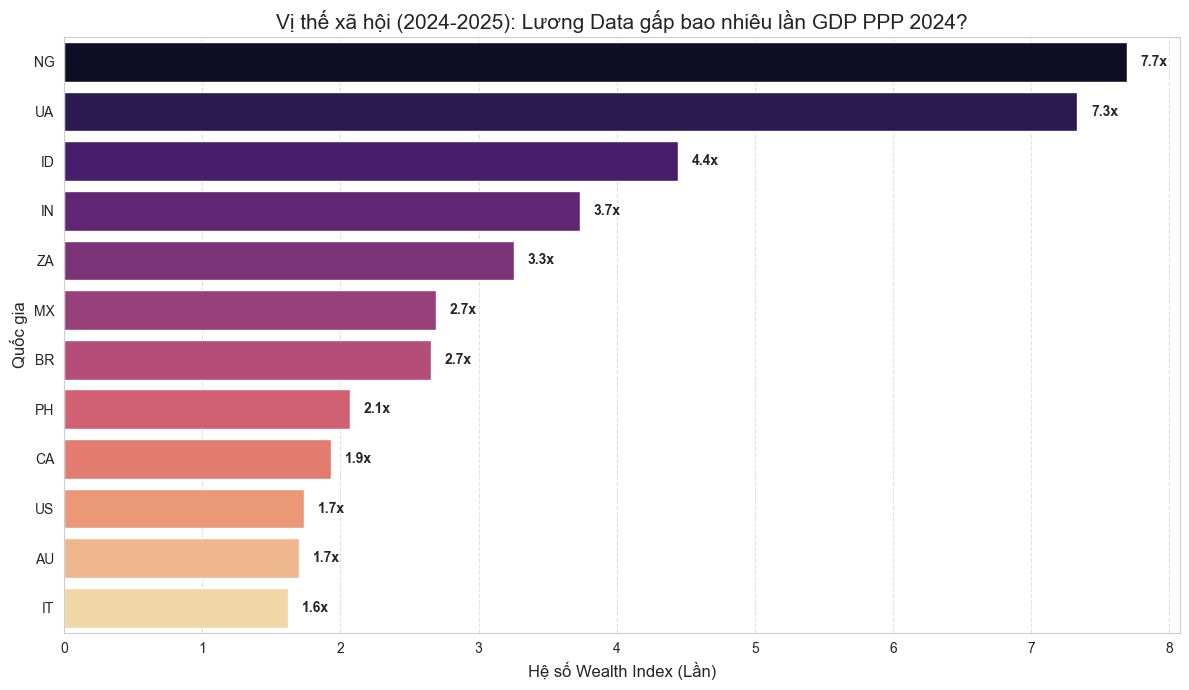

In [3]:
# --- B. Đánh giá phân tích lại ---
# 1. Tổng hợp dữ liệu
# Tính trung vị Wealth Index cho dữ liệu mới (2024-2025)
wealth_ranking_new = df_q1_new.groupby('company_location')['wealth_index'].median().sort_values(ascending=False)

# In kết quả chi tiết
print("--- Top 10 Quốc gia có Vị thế xã hội cao nhất (Dữ liệu 2024-2025) ---")
print(wealth_ranking_new.head(10))

# 2. Trực quan hóa
plt.figure(figsize=(12, 7))

# Chọn Top 12 để vẽ
top_plot = wealth_ranking_new.head(12)

# Vẽ biểu đồ
sns.barplot(x=top_plot.values, y=top_plot.index, palette='magma')

plt.title('Vị thế xã hội (2024-2025): Lương Data gấp bao nhiêu lần GDP PPP 2024?', fontsize=15)
plt.xlabel('Hệ số Wealth Index (Lần)', fontsize=12)
plt.ylabel('Quốc gia', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Thêm nhãn giá trị
for i, v in enumerate(top_plot.values):
    plt.text(v + 0.1, i, f'{v:.1f}x', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### C. Kết luận

Chúng ta có câu trả lời phù hợp với hiện tại cho câu hỏi: *"Lương $15k ở Châu Á có 'nghèo' hơn $100k ở Mỹ không?"*

**1. Câu trả lời: KHÔNG.**
Xét về vị thế xã hội và sức mua tương đối tại địa phương, nhân sự Data Science tại các nước đang phát triển thực chất có "đẳng cấp" kinh tế cao hơn đồng nghiệp tại Mỹ.

**2. Các phát hiện chính:**
* **Vị thế "Tinh hoa" tại nhóm đang phát triển:**
    * Tại các quốc gia như **Nigeria (NG), Ukraine (UA), Indonesia (ID)**, chỉ số Wealth Index dao động từ **4.0 đến 8.0**.
    * Nghĩa là một kỹ sư dữ liệu tại đây có thu nhập gấp 4-8 lần mức sống trung bình của người dân. Mức này tương đương với tầng lớp thượng lưu, cho phép họ tiếp cận các dịch vụ cao cấp và tích lũy tài sản nhanh chóng so với mặt bằng chung.
* **Vị thế "Trung lưu" tại Mỹ:**
    * Tại Mỹ, dù mức lương tuyệt đối rất cao (~$160k), nhưng chỉ số Wealth Index chỉ đạt khoảng **1.8 - 1.9**.
    * Điều này cho thấy nhân sự Data tại Mỹ chỉ có thu nhập gần gấp đôi mức trung bình, vẫn chịu áp lực lớn từ chi phí sinh hoạt (thuê nhà, y tế, giáo dục) và thuộc nhóm trung lưu.

**3. Giá trị của việc cập nhật dữ liệu (2024-2025):**
* Việc lọc bỏ dữ liệu cũ (2020-2023) và cập nhật GDP 2024 đã giúp loại bỏ "nhiễu" từ thời kỳ lương thấp trước lạm phát. Kết quả cho thấy khoảng cách vị thế xã hội giữa hai nhóm nước vẫn được duy trì, thậm chí nới rộng thêm ở một số thị trường mới nổi do đồng nội tệ mất giá so với USD (khiến lương USD trở nên giá trị hơn).

**4. Ý nghĩa thực tiễn:**
* Đối với nhân sự tại Indonesia hay Ấn Độ: Mức lương $20k - $30k không phải là "rẻ mạt". Đó là mức thu nhập mơ ước mang lại chất lượng cuộc sống vượt trội ngay tại quê nhà.

## Câu hỏi 2: Nên học gì và chọn nước nào để tối đa hóa lương trong 3 năm tới?

Lưu ý: Câu này rất nguy hiểm, như dự báo tỷ số trong bóng đá vậy, khả năng và tỷ lệ thay đổi liên tục và chẳng ai biết chắc, chỉ có giá trị tham khảo và cùng nhau bàn luận một xíu.

### 1. Mô tả câu hỏi
Thị trường công nghệ thay đổi rất nhanh. Một kỹ năng "hot" hôm nay có thể bão hòa vào ngày mai. Câu hỏi này không chỉ tìm kiếm mức lương cao nhất hiện tại, mà còn tìm kiếm **động lực tăng trưởng**.
Chúng ta sẽ phân tích dữ liệu để tìm ra:
* **Học gì (Role):** Nhóm công việc nào (AI, Data Engineering, hay Analytics) đang có tốc độ tăng lương nhanh nhất?
* **Chọn nước nào (Location):** Quốc gia nào đang trả lương cao nhất và giữ vững phong độ ổn định?

### 2. Ý nghĩa câu hỏi
* **Giá trị thực tế:**
    * Giúp sinh viên và người chuyển ngành chọn đúng "long mạch" để đầu tư thời gian học tập (ROI giáo dục cao nhất).
    * Giúp nhân sự có kinh nghiệm quyết định xem nên đào sâu vào kỹ thuật (học thêm AI/ML) hay chuyển hướng sang thị trường khác.
* **Insight:**
    * Xác định được các "ngôi sao đang lên" (Rising Stars) trong ngành dữ liệu.
    * Phân biệt được đâu là xu hướng ngắn hạn và đâu là giá trị cốt lõi dài hạn.
* **Đối tượng quan tâm:**
    * **Sinh viên/Fresher:** Đang chọn chuyên ngành hẹp.
    * **Nhân sự Mid-level:** Muốn tối ưu hóa thu nhập trong bước nhảy việc tiếp theo.

### A. Tiền xử lý dữ liệu

**Mô tả quy trình:**

Để dự đoán xu hướng cho "3 năm tới", chúng ta cần dữ liệu sạch và tập trung vào các năm gần nhất để thấy rõ độ dốc tăng trưởng.

1.  **Khởi tạo & Lọc thời gian:**
    * Load dữ liệu gốc.
    * Chỉ giữ lại dữ liệu từ năm **2022 đến 2025**. *Lý do:* Dữ liệu 2020-2021 chịu ảnh hưởng của Covid-19 và số lượng mẫu ít, có thể gây nhiễu xu hướng hiện tại.

2.  **Gom nhóm công việc:**
    * Cột `job_title` quá phân mảnh (hơn 300 loại). Cần gom về 4 nhóm kỹ năng chính để so sánh:
        * **AI/ML Engineer:** (Các từ khóa: AI, Machine Learning, NLP, Computer Vision).
        * **Data Engineer:** (Data Engineer, Architect, ETL).
        * **Data Scientist:** (Data Scientist, Research).
        * **Data Analyst:** (Analyst, BI, Analytics).
    * Loại bỏ các role quản lý (Manager/Head) để so sánh thuần túy về mặt kỹ năng chuyên môn (Individual Contributor).

3.  **Lọc quốc gia:**
    * Chỉ giữ lại các quốc gia có đủ số lượng mẫu đáng tin cậy (ví dụ: > 20 bản ghi trong giai đoạn này).
    * *Lý do:* Tránh việc một quốc gia chỉ có 1 người lương cao làm sai lệch kết luận về cả thị trường đó.

In [4]:
df_q2 = df_original.copy()
# Chỉ lấy dữ liệu từ 2022 trở lại đây để phản ánh xu hướng mới nhất
df_q2 = df_q2[df_q2['work_year'] >= 2022].copy()

# 2. Gom nhóm công việc (Job Categorization)
def categorize_skill(title):
    title = title.lower()
    # Loại bỏ Manager để tập trung vào kỹ năng (Skill)
    if any(x in title for x in ['manager', 'head', 'lead', 'director', 'vp', 'chief', 'principal']):
        return None 
    
    # Phân loại kỹ năng
    if any(x in title for x in ['ai ', 'machine learning', 'ml ', 'deep learning', 'nlp', 'vision']):
        return 'AI/ML Engineer'
    elif any(x in title for x in ['engineer', 'architect', 'etl', 'platform']):
        return 'Data Engineer'
    elif 'scientist' in title or 'research' in title:
        return 'Data Scientist'
    elif 'analyst' in title or 'analytics' in title or 'bi ':
        return 'Data Analyst'
    return None

# Áp dụng hàm và loại bỏ các dòng None (Manager hoặc Other)
df_q2['skill_group'] = df_q2['job_title'].apply(categorize_skill)
df_q2 = df_q2.dropna(subset=['skill_group'])

# 3. Lọc quốc gia tin cậy (Top Locations)
# Đếm số lượng mẫu từng quốc gia
loc_counts = df_q2['company_location'].value_counts()
# Chỉ lấy các quốc gia có trên 20 bản ghi để đảm bảo ý nghĩa thống kê
valid_locations = loc_counts[loc_counts > 20].index
df_q2 = df_q2[df_q2['company_location'].isin(valid_locations)]

print("Các nhóm kỹ năng chính được phân tích:")
print(df_q2['skill_group'].value_counts())
print("\nCác quốc gia được đưa vào so sánh:")
print(list(valid_locations))

Các nhóm kỹ năng chính được phân tích:
skill_group
Data Engineer     19070
Data Analyst      13915
Data Scientist     8042
AI/ML Engineer     4799
Name: count, dtype: int64

Các quốc gia được đưa vào so sánh:
['US', 'CA', 'GB', 'AU', 'DE', 'NL', 'LT', 'FR', 'ES', 'AT', 'IN', 'SK', 'PL', 'IE', 'LV', 'MX', 'BR', 'AR', 'ZA', 'PH', 'PT', 'NZ', 'CH', 'IT', 'EG', 'CO', 'FI']


### B. Đánh giá và Phân tích

**Phương pháp tiếp cận:**

Chúng ta sẽ tiếp cận bài toán theo 2 góc độ độc lập sau đó tổng hợp lại:

1.  **Góc độ Kỹ năng (Học gì?):**
    * Tính mức lương trung bình (Mean Salary) cho từng nhóm kỹ năng theo từng năm (2022 -> 2025).
    * Vẽ **Biểu đồ đường (Line Chart)** để quan sát độ dốc. Nhóm nào có đường đi lên dốc nhất chính là nhóm có tốc độ tăng trưởng cao nhất.

2.  **Góc độ Quốc gia (Chọn nước nào?):**
    * Tính mức lương **Trung vị (Median)** của các quốc gia.
    * Sử dụng **Boxplot** để quan sát không chỉ mức lương trung bình mà còn cả "trần lương" (max salary) và độ ổn định của thị trường đó.

3.  **Tổng hợp:**
    * Kết hợp kết quả để đưa ra khuyến nghị cụ thể (Ví dụ: Học AI và đến Mỹ, hoặc Học Data Engineering và đến Anh).

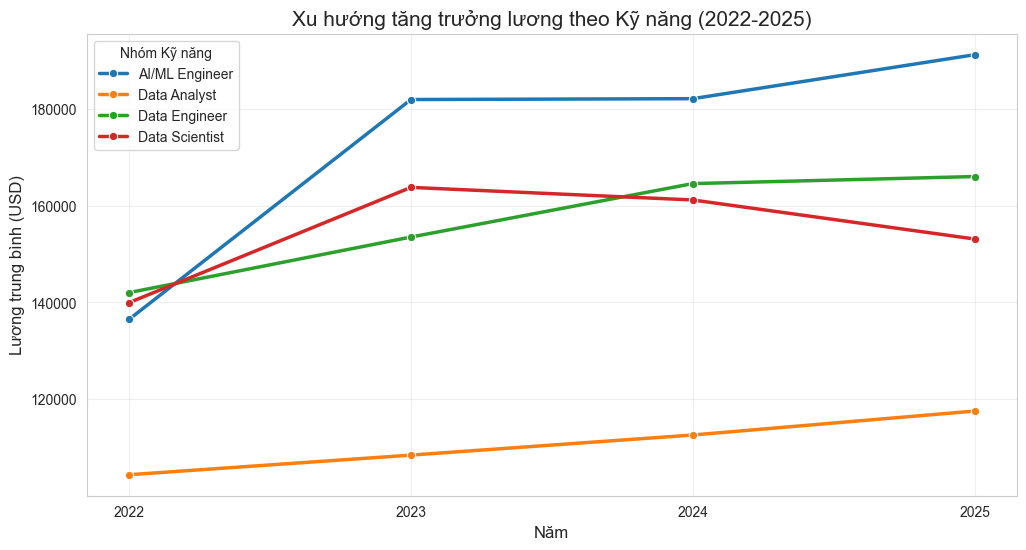

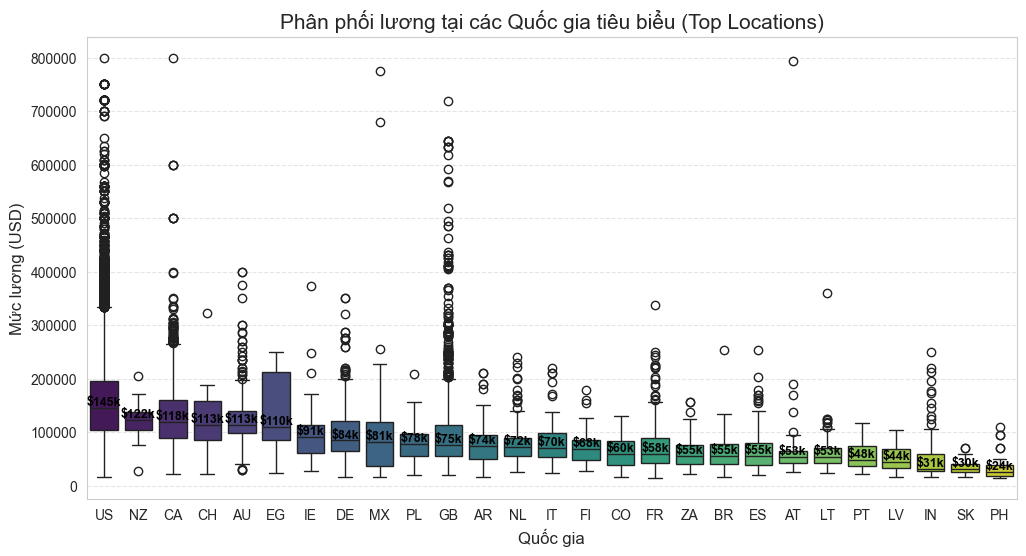

In [5]:
# --- PHẦN 1: PHÂN TÍCH KỸ NĂNG (HỌC GÌ?) ---

# Tính lương trung bình theo Năm và Nhóm kỹ năng
skill_trend = df_q2.groupby(['work_year', 'skill_group'])['salary_in_usd'].mean().reset_index()

plt.figure(figsize=(12, 6))
# Vẽ biểu đồ xu hướng
sns.lineplot(data=skill_trend, x='work_year', y='salary_in_usd', hue='skill_group', 
             marker='o', linewidth=2.5, palette='tab10')

plt.title('Xu hướng tăng trưởng lương theo Kỹ năng (2022-2025)', fontsize=15)
plt.ylabel('Lương trung bình (USD)', fontsize=12)
plt.xlabel('Năm', fontsize=12)
plt.legend(title='Nhóm Kỹ năng')
plt.grid(True, alpha=0.3)
plt.xticks([2022, 2023, 2024, 2025]) # Đảm bảo trục X hiển thị số nguyên
plt.show()

# --- PHẦN 2: PHÂN TÍCH QUỐC GIA (CHỌN NƯỚC NÀO?) ---

# Sắp xếp quốc gia theo lương trung vị giảm dần để vẽ boxplot đẹp
loc_order = df_q2.groupby('company_location')['salary_in_usd'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_q2, x='company_location', y='salary_in_usd', order=loc_order, palette='viridis')

plt.title('Phân phối lương tại các Quốc gia tiêu biểu (Top Locations)', fontsize=15)
plt.ylabel('Mức lương (USD)', fontsize=12)
plt.xlabel('Quốc gia', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Hiển thị giá trị trung vị lên biểu đồ
medians = df_q2.groupby('company_location')['salary_in_usd'].median().reindex(loc_order)
for i, m in enumerate(medians):
    plt.text(i, m + 5000, f'${int(m/1000)}k', ha='center', color='black', fontweight='bold', fontsize=9)

plt.show()

### C. Kết luận

Dựa trên dữ liệu phân tích từ 2022 đến nay, chúng ta có câu trả lời chiến lược cho câu hỏi: *"Học gì và Chọn nước nào để tối ưu thu nhập trong 3 năm tới?"*

**1. Học gì? -> Đầu tư vào AI/Machine Learning Engineer.**
* **Dữ liệu chỉ ra:** Đường xu hướng lương của nhóm **AI/ML Engineer** có độ dốc lớn nhất trong các nhóm kỹ năng. Mức lương trung bình của nhóm này đã vượt ngưỡng **$180,000/năm** vào 2024-2025.
* **Lựa chọn an toàn:** **Data Engineer** là lựa chọn số 2 vững chắc. Dù không "bùng nổ" như AI, nhưng xu hướng lương rất ổn định và luôn cao hơn nhóm Data Analyst/Scientist thuần túy, do nhu cầu xây dựng hạ tầng dữ liệu vẫn rất lớn. Bên cạnh sự phát triển của thuật toán, để có thể ứng dụng được các nghiên cứu vào đời sống chúng ta cần phải xây dựng cơ sở hạ tầng đủ tốt và phải đảm bảo an toàn thông tin nữa.

**2. Chọn nước nào? -> Mỹ (US) là đích đến tối thượng.**
* **Thống trị tuyệt đối:** Boxplot cho thấy Mỹ không chỉ có mức lương trung vị cao nhất (~$155k - $160k) mà "trần lương" (max salary) cũng cao nhất thế giới (lên tới $700k+).
* **Các lựa chọn thay thế:** Nếu không thể tiếp cận thị trường Mỹ, **Canada (CA)** và **Anh (GB)** là các lựa chọn hạng 2 tốt nhất, với mức lương trung vị dao động quanh mức **$90k - $100k**.

**3. Lời khuyên hành động:**
* **Ngắn hạn (1 năm):** Tập trung nâng cấp kỹ năng liên quan đến **Triển khai mô hình (MLOps)** hoặc **GenAI** để bắt kịp đà tăng trưởng nóng.
* **Chiến lược địa lý:** Nếu đang ở Việt Nam/Châu Á, hãy ưu tiên tìm kiếm các job **Remote cho công ty Mỹ, Canada, Anh**. Nếu có ý định định cư (Relocate), Mỹ vẫn là nơi duy nhất giúp bạn tối đa hóa tài sản ròng nhanh nhất bất chấp chi phí sinh hoạt cao. Tất nhiên, nếu bạn thuộc các nước phát triển và muốn giúp đỡ gia đình, hãy đi du học và làm việc tại những thị trường này , bạn có thể không sống như giới "thượng lưu" ở đây (như câu hỏi 1 đã phân tích), nhưng bạn gửi vài phần lương của bạn về cho gia đình, gia đình bạn sẽ bước chân vào giới "thượng lưu" ở quốc mẫu.